In [78]:
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = "../../../../theming/fonts/AtkinsonHyperlegibleNext-Regular.ttf"

# Register font with matplotlib
fm.fontManager.addfont(font_path)

# Get the name inside the font file
prop = fm.FontProperties(fname=font_path)

# Set it globally
mpl.rcParams['font.family'] = prop.get_name()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

grey = "#8a8a8a"


# ==== Drawing helpers ====
def draw_filled_circle(img, cx, cy, r, color):
    H, W, _ = img.shape
    y, x = np.ogrid[:H, :W]
    mask = (x - cx)**2 + (y - cy)**2 <= r**2
    img[mask] = color
    return img

def draw_filled_ellipse(img, cx, cy, rx, ry, color):
    H, W, _ = img.shape
    y, x = np.ogrid[:H, :W]
    mask = ((x - cx)/rx)**2 + ((y - cy)/ry)**2 <= 1
    img[mask] = color
    return img

def draw_filled_triangle(img, pts, color):
    H, W, _ = img.shape
    (x1, y1), (x2, y2), (x3, y3) = pts
    
    # Simple approach: use barycentric coordinates
    xmin = max(0, min(x1, x2, x3))
    xmax = min(W-1, max(x1, x2, x3))
    ymin = max(0, min(y1, y2, y3))
    ymax = min(H-1, max(y1, y2, y3))
    
    for y in range(ymin, ymax+1):
        for x in range(xmin, xmax+1):
            # Calculate barycentric coordinates
            denom = ((y2 - y3)*(x1 - x3) + (x3 - x2)*(y1 - y3))
            if abs(denom) < 0.01:
                continue
                
            a = ((y2 - y3)*(x - x3) + (x3 - x2)*(y - y3)) / denom
            b = ((y3 - y1)*(x - x3) + (x1 - x3)*(y - y3)) / denom
            c = 1 - a - b
            
            # Check if point is inside triangle
            if a >= 0 and b >= 0 and c >= 0:
                img[y, x] = color
    
    return img

def draw_arc(img, cx, cy, r, theta1, theta2, color, thickness=1):
    H, W, _ = img.shape
    t = np.linspace(theta1, theta2, 100)
    xs = (cx + r*np.cos(t)).astype(int)
    ys = (cy + r*np.sin(t)).astype(int)
    for (x, y) in zip(xs, ys):
        for dx in range(-thickness, thickness+1):
            for dy in range(-thickness, thickness+1):
                nx, ny = x+dx, y+dy
                if 0 <= nx < W and 0 <= ny < H:
                    img[ny, nx] = color
    return img

# ==== Build cute cat image ====
H, W, C = 32, 32, 3
cat = np.ones((H, W, C), dtype=float)
# Soft pastel background
cat[:] = [0.95, 0.92, 0.98]  

# Main cat color - softer orange
cat_color = np.array([1.0, 0.75, 0.45])

# Ears FIRST - positioned above where the head will be
head_cy, head_ry = H//2 + 4, 10
head_top_y = head_cy - head_ry  # ≈ 10

ear_base_y = head_top_y + 1     # bases slightly above head edge (≈ 11)
ear_tip_y  = ear_base_y - 8     # tip height (≈ 3)

# Outer ears (slightly wider, symmetric)
ear_color = np.array([1.0, 0.70, 0.40])
left_outer  = [(7, ear_base_y + 3), (9, ear_tip_y + 2), (14, ear_base_y + 2)]
right_outer = [(17, ear_base_y + 2), (22, ear_tip_y + 2), (25, ear_base_y + 3)]
cat = draw_filled_triangle(cat, left_outer,  ear_color)
cat = draw_filled_triangle(cat, right_outer, ear_color)



# Inner ears (inset triangles for a tidy border reveal)
inner_ear = np.array([1.0, 0.75, 0.80])
left_inner  = [(8,  ear_base_y+2), (9, ear_tip_y+4), (13, ear_base_y+1)]
right_inner = [(18, ear_base_y+1), (22, ear_tip_y+4), (24, ear_base_y+2)]
cat = draw_filled_triangle(cat, left_inner,  inner_ear)
cat = draw_filled_triangle(cat, right_inner, inner_ear)

# Head - slightly oval for cuteness (drawn AFTER ears so it overlaps them properly)
cat = draw_filled_ellipse(cat, W//2, H//2+4, 11, 10, cat_color)

# Cheek patches for extra cuteness
cheek_color = cat_color * 1.05
cat = draw_filled_circle(cat, 8, 20, 3, cheek_color)
cat = draw_filled_circle(cat, 24, 20, 3, cheek_color)

# Stripes on forehead
stripe_color = ear_color * 0.95
for i in range(3):
    y = 12 + i * 2
    cat[y:y+1, 14:18] = stripe_color

# Big sparkly eyes
eye_white = [1.0, 1.0, 1.0]
cat = draw_filled_ellipse(cat, 11, 18, 3, 4, eye_white)
cat = draw_filled_ellipse(cat, 21, 18, 3, 4, eye_white)

# Pupils
pupil = [0.1, 0.1, 0.15]
cat = draw_filled_ellipse(cat, 11, 18, 2, 3, pupil)
cat = draw_filled_ellipse(cat, 21, 18, 2, 3, pupil)

# Eye sparkles
sparkle = [1.0, 1.0, 1.0]
cat[16:17, 10:11] = sparkle
cat[16:17, 20:21] = sparkle

# Cute W-shaped mouth
mouth_color = [0.4, 0.3, 0.3]
cat = draw_arc(cat, 16, 24, 4, 0, np.pi , mouth_color, thickness=0)

# Whiskers
whisker_color = [0.3, 0.3, 0.3]
# Left whiskers
cat[19:20, 2:7] = whisker_color
cat[21:22, 3:8] = whisker_color
# Right whiskers
cat[19:20, 25:30] = whisker_color
cat[21:22, 24:29] = whisker_color

# Pink blush circles
blush = np.array([1.0, 0.85, 0.90])
cat = draw_filled_circle(cat, 7, 21, 1, blush)
cat = draw_filled_circle(cat, 25, 21, 1, blush)

# Little paws at bottom
paw_color = cat_color
cat = draw_filled_ellipse(cat, 10, 28, 3, 2, paw_color)
cat = draw_filled_ellipse(cat, 22, 28, 3, 2, paw_color)

# Paw pads
nose = [1.0, 0.60, 0.70]

pad_color = nose
cat = draw_filled_circle(cat, 10, 28, 1, pad_color)
cat = draw_filled_circle(cat, 22, 28, 1, pad_color)

# Pink nose
nose = [1.0, 0.60, 0.70]
cat = draw_filled_triangle(cat, [(14, 22), (16, 20), (18, 22)], nose)


cat = np.clip(cat, 0, 1)

# ==== Channel grayscale ====
def to_gray_from_channel(img, ch):
    g = img[..., ch]
    return np.stack([g, g, g], axis=-1)

R = to_gray_from_channel(cat, 0)
G = to_gray_from_channel(cat, 1)
B = to_gray_from_channel(cat, 2)

# ==== Plot with grid lines ====
scale = 20  # Pixels per grid cell

def upscale_with_grid(im, scale=20, grid_width=1):
    # Upscale the image
    upscaled = np.repeat(np.repeat(im, scale, 0), scale, 1)
    H, W, _ = upscaled.shape
    
    # Add grid lines (darker color)
    grid_color = np.array([0.3, 0.3, 0.3])
    
    # Vertical lines
    for x in range(0, W+1, scale):
        if x < W:
            upscaled[:, x:min(x+grid_width, W)] = grid_color
    
    # Horizontal lines  
    for y in range(0, H+1, scale):
        if y < H:
            upscaled[y:min(y+grid_width, H), :] = grid_color
    
    return upscaled

# Display all figures together
# First figure: 2x2 grid with all channels
images = [cat, R, G, B]
titles = ["RGB (Full Color)", "Red Channel", "Green Channel", "Blue Channel"]

# Create all three figures at once
fig, axes = plt.subplots(1, 4, figsize=(16, 5), facecolor="none")

# First four subplots: RGB and channels
ax_list = [axes[0], axes[1], axes[2], axes[3]]
for ax, img, title in zip(ax_list, images, titles):
    ax.imshow(upscale_with_grid(img, scale=15))
    ax.set_title(title, fontsize=18, fontweight='bold', color=grey)
    ax.set_facecolor("none")


# Add some tick marks for reference
axes[0].set_xticks(np.arange(0, 32*15+1, 15*8))
axes[0].set_xticklabels(np.arange(0, 33, 8), fontsize=12, color=grey)
axes[0].set_yticks(np.arange(0, 32*15+1, 15*8))
axes[0].set_yticklabels(np.arange(0, 33, 8), fontsize=12, color=grey)
axes[0].tick_params(axis='both', which='major', labelsize=12, color=grey)

for ax in ax_list[1:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("cat_pixel.png", dpi=200, bbox_inches="tight", transparent=True)


NameError: name 'nose' is not defined

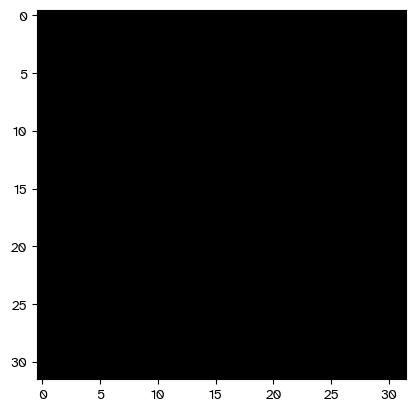

In [33]:
plt.imshow(cat - draw_filled_triangle(cat, left_outer,  ear_color)
)

/var/folders/y9/f2jq2rkn6h16kl4g9j02c2800000gn/T/ipykernel_60773/1293641511.py:206: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from current font.
  plt.tight_layout()
/Users/matthewfisher/.pyenv/versions/3.11.4/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


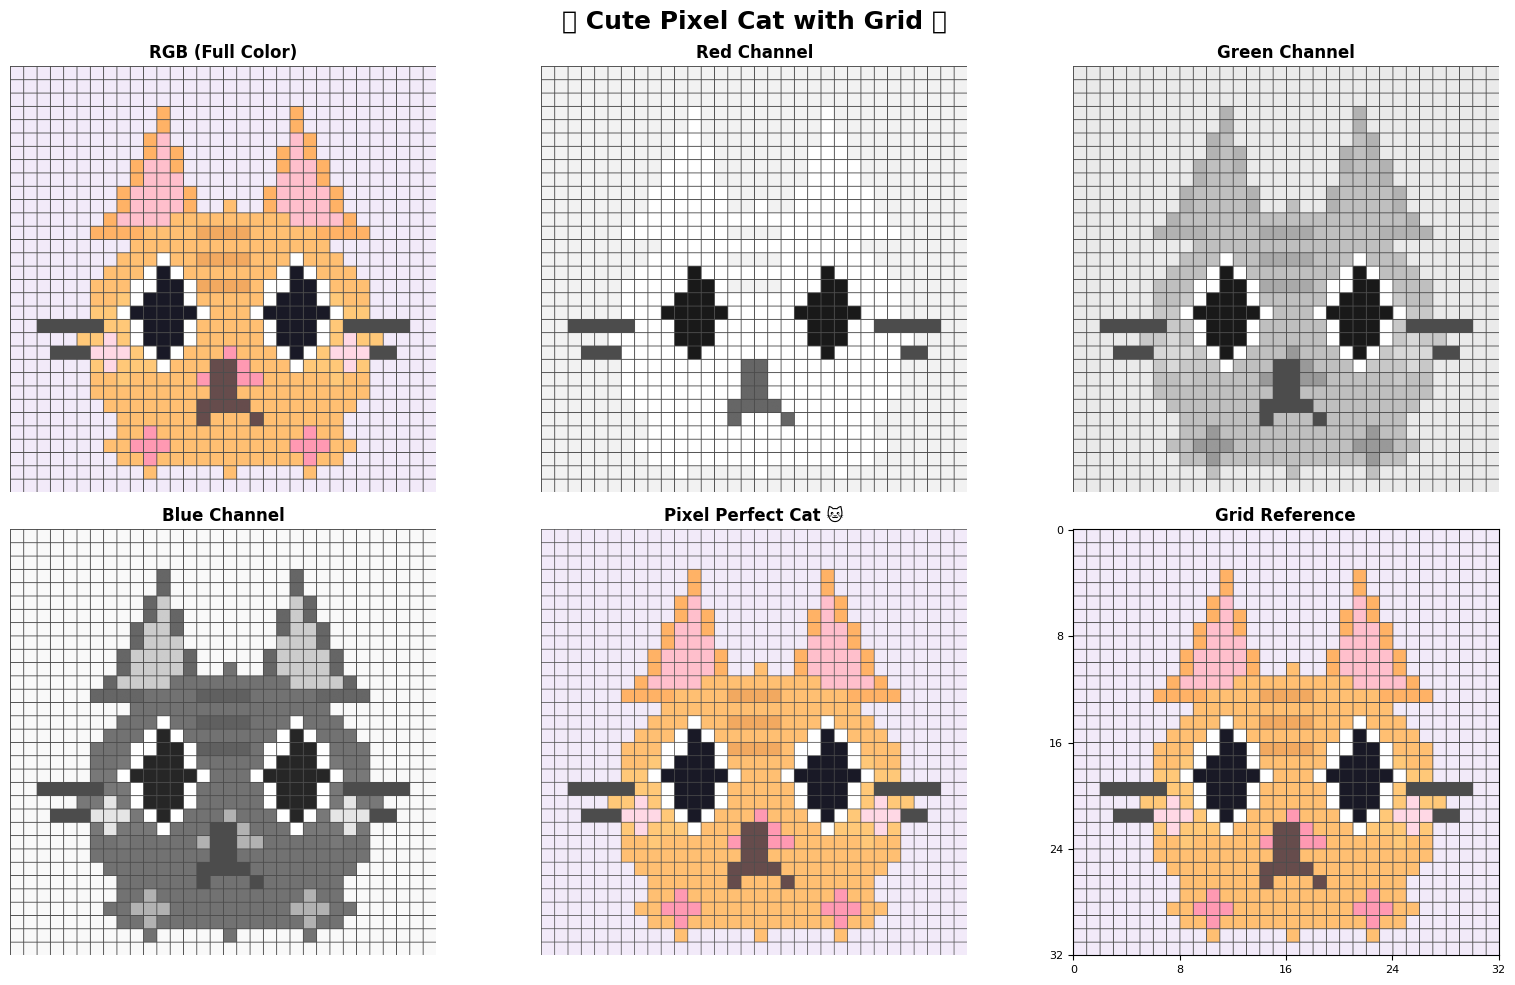

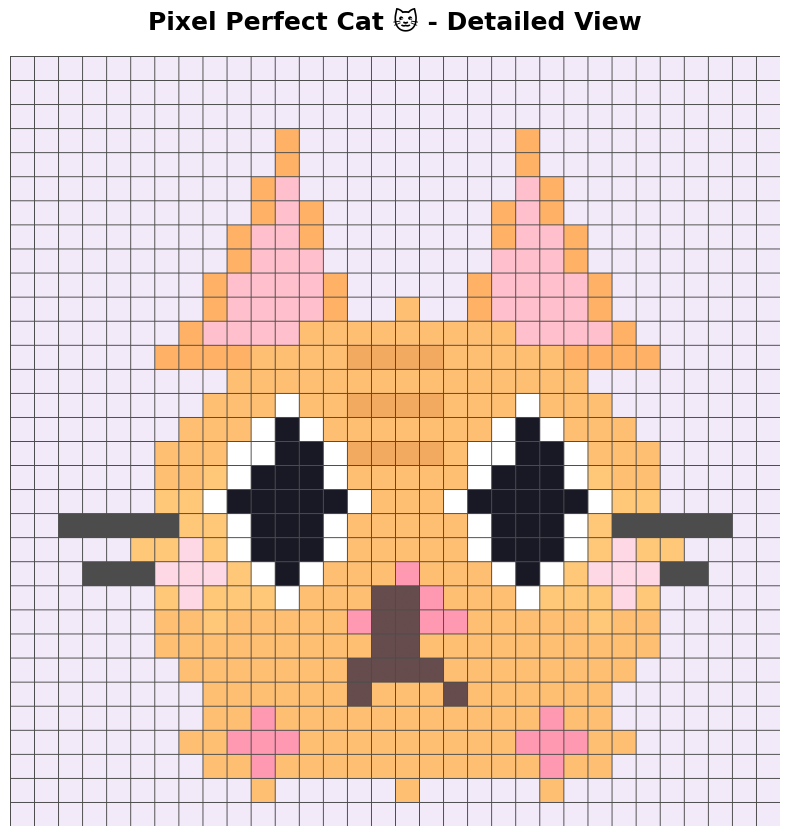

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==== Drawing helpers ====
def draw_filled_circle(img, cx, cy, r, color):
    H, W, _ = img.shape
    y, x = np.ogrid[:H, :W]
    mask = (x - cx)**2 + (y - cy)**2 <= r**2
    img[mask] = color
    return img

def draw_filled_ellipse(img, cx, cy, rx, ry, color):
    H, W, _ = img.shape
    y, x = np.ogrid[:H, :W]
    mask = ((x - cx)/rx)**2 + ((y - cy)/ry)**2 <= 1
    img[mask] = color
    return img

def draw_filled_triangle(img, pts, color):
    H, W, _ = img.shape
    (x1, y1), (x2, y2), (x3, y3) = pts
    
    # Simple approach: use barycentric coordinates
    xmin = max(0, min(x1, x2, x3))
    xmax = min(W-1, max(x1, x2, x3))
    ymin = max(0, min(y1, y2, y3))
    ymax = min(H-1, max(y1, y2, y3))
    
    for y in range(ymin, ymax+1):
        for x in range(xmin, xmax+1):
            # Calculate barycentric coordinates
            denom = ((y2 - y3)*(x1 - x3) + (x3 - x2)*(y1 - y3))
            if abs(denom) < 0.01:
                continue
                
            a = ((y2 - y3)*(x - x3) + (x3 - x2)*(y - y3)) / denom
            b = ((y3 - y1)*(x - x3) + (x1 - x3)*(y - y3)) / denom
            c = 1 - a - b
            
            # Check if point is inside triangle
            if a >= 0 and b >= 0 and c >= 0:
                img[y, x] = color
    
    return img

def draw_arc(img, cx, cy, r, theta1, theta2, color, thickness=1):
    H, W, _ = img.shape
    t = np.linspace(theta1, theta2, 100)
    xs = (cx + r*np.cos(t)).astype(int)
    ys = (cy + r*np.sin(t)).astype(int)
    for (x, y) in zip(xs, ys):
        for dx in range(-thickness, thickness+1):
            for dy in range(-thickness, thickness+1):
                nx, ny = x+dx, y+dy
                if 0 <= nx < W and 0 <= ny < H:
                    img[ny, nx] = color
    return img

# ==== Build cute cat image ====
H, W, C = 32, 32, 3
cat = np.ones((H, W, C), dtype=float)
# Soft pastel background
cat[:] = [0.95, 0.92, 0.98]  

# Main cat color - softer orange
cat_color = np.array([1.0, 0.75, 0.45])

# Ears FIRST - positioned above where the head will be
ear_color = np.array([1.0, 0.70, 0.40])
cat = draw_filled_triangle(cat, [(6, 12), (11, 3), (14, 12)], ear_color)
cat = draw_filled_triangle(cat, [(18, 12), (21, 3), (26, 12)], ear_color)

# Inner ear pink
inner_ear = np.array([1.0, 0.75, 0.80])
cat = draw_filled_triangle(cat, [(8, 11), (11, 5), (13, 11)], inner_ear)
cat = draw_filled_triangle(cat, [(19, 11), (21, 5), (24, 11)], inner_ear)

# Head - slightly oval for cuteness (drawn AFTER ears so it overlaps them properly)
cat = draw_filled_ellipse(cat, W//2, H//2+4, 11, 10, cat_color)

# Cheek patches for extra cuteness
cheek_color = cat_color * 1.05
cat = draw_filled_circle(cat, 8, 20, 3, cheek_color)
cat = draw_filled_circle(cat, 24, 20, 3, cheek_color)

# Stripes on forehead
stripe_color = ear_color * 0.95
for i in range(3):
    y = 12 + i * 2
    cat[y:y+1, 14:18] = stripe_color

# Big sparkly eyes
eye_white = [1.0, 1.0, 1.0]
cat = draw_filled_ellipse(cat, 11, 18, 3, 4, eye_white)
cat = draw_filled_ellipse(cat, 21, 18, 3, 4, eye_white)

# Pupils
pupil = [0.1, 0.1, 0.15]
cat = draw_filled_ellipse(cat, 11, 18, 2, 3, pupil)
cat = draw_filled_ellipse(cat, 21, 18, 2, 3, pupil)

# Eye sparkles
sparkle = [1.0, 1.0, 1.0]
cat[16:17, 10:11] = sparkle
cat[16:17, 20:21] = sparkle

# Pink nose
nose = [1.0, 0.60, 0.70]
cat = draw_filled_triangle(cat, [(16, 21), (14, 23), (18, 23)], nose)

# Cute W-shaped mouth
mouth_color = [0.4, 0.3, 0.3]
cat = draw_arc(cat, 14, 24, 2, -np.pi/4, np.pi/2, mouth_color, thickness=0)
cat = draw_arc(cat, 18, 24, 2, np.pi/2, np.pi + np.pi/4, mouth_color, thickness=0)

# Whiskers
whisker_color = [0.3, 0.3, 0.3]
# Left whiskers
cat[19:20, 2:7] = whisker_color
cat[21:22, 3:8] = whisker_color
# Right whiskers
cat[19:20, 25:30] = whisker_color
cat[21:22, 24:29] = whisker_color

# Pink blush circles
blush = np.array([1.0, 0.85, 0.90])
cat = draw_filled_circle(cat, 7, 21, 1, blush)
cat = draw_filled_circle(cat, 25, 21, 1, blush)

# Little paws at bottom
paw_color = cat_color
cat = draw_filled_ellipse(cat, 10, 28, 3, 2, paw_color)
cat = draw_filled_ellipse(cat, 22, 28, 3, 2, paw_color)

# Paw pads
pad_color = nose
cat = draw_filled_circle(cat, 10, 28, 1, pad_color)
cat = draw_filled_circle(cat, 22, 28, 1, pad_color)

cat = np.clip(cat, 0, 1)

# ==== Channel grayscale ====
def to_gray_from_channel(img, ch):
    g = img[..., ch]
    return np.stack([g, g, g], axis=-1)

R = to_gray_from_channel(cat, 0)
G = to_gray_from_channel(cat, 1)
B = to_gray_from_channel(cat, 2)

# ==== Plot with grid lines ====
scale = 20  # Pixels per grid cell

def upscale_with_grid(im, scale=20, grid_width=1):
    # Upscale the image
    upscaled = np.repeat(np.repeat(im, scale, 0), scale, 1)
    H, W, _ = upscaled.shape
    
    # Add grid lines (darker color)
    grid_color = np.array([0.3, 0.3, 0.3])
    
    # Vertical lines
    for x in range(0, W+1, scale):
        if x < W:
            upscaled[:, x:min(x+grid_width, W)] = grid_color
    
    # Horizontal lines  
    for y in range(0, H+1, scale):
        if y < H:
            upscaled[y:min(y+grid_width, H), :] = grid_color
    
    return upscaled

# Display all figures together
# First figure: 2x2 grid with all channels
images = [cat, R, G, B]
titles = ["RGB (Full Color)", "Red Channel", "Green Channel", "Blue Channel"]

# Create all three figures at once
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("✨ Cute Pixel Cat with Grid ✨", fontsize=18, fontweight='bold')

# First four subplots: RGB and channels
ax_list = [axes[0,0], axes[0,1], axes[0,2], axes[1,0]]
for ax, img, title in zip(ax_list, images, titles):
    ax.imshow(upscale_with_grid(img, scale=15))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis("off")

# Fifth subplot: Larger cat view
axes[1,1].imshow(upscale_with_grid(cat, scale=18))
axes[1,1].set_title("Pixel Perfect Cat 🐱", fontsize=12, fontweight='bold')
axes[1,1].axis("off")

# Sixth subplot: With coordinate reference
cat_with_coords = upscale_with_grid(cat, scale=15, grid_width=1)
axes[1,2].imshow(cat_with_coords)
axes[1,2].set_title("Grid Reference", fontsize=12, fontweight='bold')
# Add some tick marks for reference
axes[1,2].set_xticks(np.arange(0, 32*15+1, 15*8))
axes[1,2].set_xticklabels(np.arange(0, 33, 8), fontsize=8)
axes[1,2].set_yticks(np.arange(0, 32*15+1, 15*8))
axes[1,2].set_yticklabels(np.arange(0, 33, 8), fontsize=8)
axes[1,2].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.show()

# Also create a single large view for detail
fig2, ax2 = plt.subplots(figsize=(10, 10))
ax2.imshow(upscale_with_grid(cat, scale=25))
ax2.set_title("Pixel Perfect Cat 🐱 - Detailed View", fontsize=18, fontweight='bold', pad=20)
ax2.axis("off")
plt.show()